# Week 2: Spectrum, Sampling, and Signal Analysis

ECE 5377/7377 Embedded Wireless Design Laboratory

Python/Jupyter version of the Week 2 numerical demonstration. Run this notebook after the prediction slide.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.grid": True,
    "font.size": 11,
})

print("WEEK 2 PYTHON NOTEBOOK DEMONSTRATION")
print("Spectrum, sampling, and signal analysis")
print()

WEEK 2 PYTHON NOTEBOOK DEMONSTRATION
Spectrum, sampling, and signal analysis



## 1. Three-tone signal

Prediction: What peaks should appear in the two-sided spectrum?

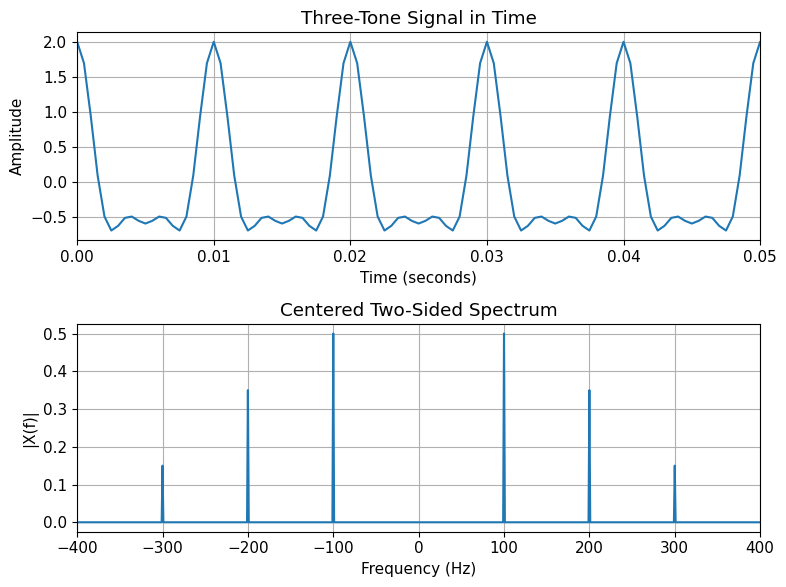

Expected positive-frequency peaks: 100, 200, and 300 Hz


In [2]:
Fs = 2000              # Samples per second
Tobs = 1               # Observation duration in seconds
N = int(Fs * Tobs)     # Number of samples
n = np.arange(N)
t = n / Fs

f1 = 100
f2 = 200
f3 = 300

x = (np.cos(2*np.pi*f1*t)
     + 0.7*np.cos(2*np.pi*f2*t)
     + 0.3*np.cos(2*np.pi*f3*t))

# Centered, two-sided FFT

X = np.fft.fftshift(np.fft.fft(x)) / N
f = (np.arange(-N/2, N/2) * (Fs/N))

fig, ax = plt.subplots(2, 1, figsize=(8, 6))
ax[0].plot(t, x)
ax[0].set_xlim(0, 0.05)
ax[0].set_xlabel("Time (seconds)")
ax[0].set_ylabel("Amplitude")
ax[0].set_title("Three-Tone Signal in Time")

ax[1].plot(f, np.abs(X))
ax[1].set_xlim(-400, 400)
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("|X(f)|")
ax[1].set_title("Centered Two-Sided Spectrum")
plt.tight_layout()
plt.show()

print(f"Expected positive-frequency peaks: {f1}, {f2}, and {f3} Hz")

## 2. FFT resolution and record duration

Prediction: What happens to \(\Delta f\) when the observation time doubles while the sampling rate stays fixed?

In [ ]:
FsR = 1000

# One-second record
Nshort = 1000
t_short = np.arange(Nshort) / FsR
x_short = np.cos(2*np.pi*100*t_short) + 0.8*np.cos(2*np.pi*100.5*t_short)
X_short = np.fft.fftshift(np.fft.fft(x_short)) / Nshort
f_short = (np.arange(-Nshort/2, Nshort/2) * (FsR/Nshort))

# Two-second record
Nlong = 2000
t_long = np.arange(Nlong) / FsR
x_long = np.cos(2*np.pi*100*t_long) + 0.8*np.cos(2*np.pi*100.5*t_long)
X_long = np.fft.fftshift(np.fft.fft(x_long)) / Nlong
f_long = (np.arange(-Nlong/2, Nlong/2) * (FsR/Nlong))

delta_f_short = FsR / Nshort
delta_f_long = FsR / Nlong

print(f"One-second record: Delta f = {delta_f_short:.2f} Hz")
print(f"Two-second record: Delta f = {delta_f_long:.2f} Hz")
print()

fig, ax = plt.subplots(2, 1, figsize=(8, 6))
ax[0].plot(f_short, np.abs(X_short))
ax[0].set_xlim(95, 106)
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("|X(f)|")
ax[0].set_title(f"One-Second Record: Delta f = {delta_f_short:.1f} Hz")

ax[1].plot(f_long, np.abs(X_long))
ax[1].set_xlim(95, 106)
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("|X(f)|")
ax[1].set_title(f"Two-Second Record: Delta f = {delta_f_long:.1f} Hz")
plt.tight_layout()
plt.show()

## 3. Rectangular pulse and sinc spectrum

Prediction: For \(T_p=0.25\) s, where should the first sinc zero pair appear?

In [ ]:
Fs_rect = 2000
Tspan = 2
t_rect = np.arange(-Tspan/2, Tspan/2, 1/Fs_rect)

Tp = 0.25
x_rect = (np.abs(t_rect) <= Tp/2).astype(float)
Nrect = len(x_rect)

# The time record is centered around zero, so use ifftshift before fft.
X_rect = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x_rect)))
X_rect = np.abs(X_rect)
X_rect = X_rect / np.max(X_rect)
f_rect = np.arange(-Nrect/2, Nrect/2) * (Fs_rect/Nrect)

first_zero = 1 / Tp

print(f"Pulse duration: {Tp:.3f} seconds")
print(f"Expected first zero pair: +/- {first_zero:.2f} Hz")
print()

fig, ax = plt.subplots(2, 1, figsize=(8, 6))
ax[0].plot(t_rect, x_rect)
ax[0].set_xlim(-0.5, 0.5)
ax[0].set_ylim(-0.1, 1.2)
ax[0].set_xlabel("Time (seconds)")
ax[0].set_ylabel("Amplitude")
ax[0].set_title(f"Rectangular Pulse, T_p = {Tp:.2f} s")

ax[1].plot(f_rect, X_rect, label="FFT magnitude")
ax[1].axvline(first_zero, linestyle="--", label="Expected first zeros")
ax[1].axvline(-first_zero, linestyle="--")
ax[1].set_xlim(-20, 20)
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Normalized magnitude")
ax[1].set_title("Sinc-Shaped Spectrum")
ax[1].legend()
plt.tight_layout()
plt.show()

## 4. Autocorrelation: sinusoid versus noise

Autocorrelation compares a signal with shifted copies of itself.

In [ ]:
def biased_autocorrelation(x):
    """Return biased full autocorrelation and integer lags."""
    x = np.asarray(x)
    N = len(x)
    r = np.correlate(x, x, mode="full") / N
    lags = np.arange(-(N-1), N)
    return r, lags

Fs_corr = 1000
Ncorr = 1000
t_corr = np.arange(Ncorr) / Fs_corr

x_sin = np.cos(2*np.pi*50*t_corr)
x_noise = rng.standard_normal(Ncorr)

R_sin, lags = biased_autocorrelation(x_sin)
R_noise, _ = biased_autocorrelation(x_noise)

# Normalize so the shapes are easy to compare.
R_sin = R_sin / np.max(np.abs(R_sin))
R_noise = R_noise / np.max(np.abs(R_noise))

fig, ax = plt.subplots(2, 1, figsize=(8, 6))
ax[0].plot(lags, R_sin)
ax[0].set_xlim(-100, 100)
ax[0].set_xlabel("Lag (samples)")
ax[0].set_ylabel("Normalized correlation")
ax[0].set_title("Autocorrelation of a 50 Hz Sinusoid")

ax[1].plot(lags, R_noise)
ax[1].set_xlim(-100, 100)
ax[1].set_xlabel("Lag (samples)")
ax[1].set_ylabel("Normalized correlation")
ax[1].set_title("Autocorrelation of White Noise")
plt.tight_layout()
plt.show()

## 5. FFT and PSD: clean versus noisy signal

The PSD estimate is computed with a simple Welch-style average so the notebook does not require SciPy.

In [ ]:
def simple_welch_psd(x, fs, nperseg=512, noverlap=256, nfft=2048):
    """One-sided Welch PSD estimate using a Hann window and 50% overlap."""
    x = np.asarray(x)
    step = nperseg - noverlap
    if step <= 0:
        raise ValueError("nperseg must be greater than noverlap")
    window = np.hanning(nperseg)
    scale = fs * np.sum(window**2)
    starts = np.arange(0, len(x) - nperseg + 1, step)
    psd_segments = []
    for start in starts:
        segment = x[start:start+nperseg]
        spectrum = np.fft.rfft(segment * window, n=nfft)
        psd = (np.abs(spectrum)**2) / scale
        if nfft % 2 == 0:
            psd[1:-1] *= 2
        else:
            psd[1:] *= 2
        psd_segments.append(psd)
    Pxx = np.mean(psd_segments, axis=0)
    f_welch = np.fft.rfftfreq(nfft, d=1/fs)
    return f_welch, Pxx

FsP = 2000
TobsP = 2
NP = int(FsP * TobsP)
tP = np.arange(NP) / FsP

x_clean = np.cos(2*np.pi*100*tP) + 0.7*np.cos(2*np.pi*200*tP)
signal_power = np.mean(np.abs(x_clean)**2)

SNRdB = 0
noise_power = signal_power / 10**(SNRdB/10)
noise = np.sqrt(noise_power) * rng.standard_normal(x_clean.shape)
x_noisy = x_clean + noise

X_clean = np.fft.fftshift(np.fft.fft(x_clean)) / NP
X_noisy = np.fft.fftshift(np.fft.fft(x_noisy)) / NP
fP = np.arange(-NP/2, NP/2) * (FsP/NP)

f_welch, P_clean = simple_welch_psd(x_clean, FsP, nperseg=512, noverlap=256, nfft=2048)
_, P_noisy = simple_welch_psd(x_noisy, FsP, nperseg=512, noverlap=256, nfft=2048)

fig, ax = plt.subplots(2, 1, figsize=(8, 6))
ax[0].plot(fP, np.abs(X_clean), label="Clean")
ax[0].plot(fP, np.abs(X_noisy), label="Noisy")
ax[0].set_xlim(-400, 400)
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("FFT magnitude")
ax[0].set_title("FFT: Clean and Noisy Records")
ax[0].legend()

ax[1].plot(f_welch, 10*np.log10(P_clean + np.finfo(float).eps), label="Clean")
ax[1].plot(f_welch, 10*np.log10(P_noisy + np.finfo(float).eps), label="Noisy")
ax[1].set_xlim(0, 400)
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("PSD (dB/Hz)")
ax[1].set_title("Welch PSD Estimates")
ax[1].legend()
plt.tight_layout()
plt.show()

print(f"Clean signal power: {signal_power:.4f}")
print(f"Target noise power: {noise_power:.4f}")
print(f"Measured noise power: {np.mean(np.abs(noise)**2):.4f}")
print()

## 6. Samples per period and cycles in the record

This mirrors Board 4.

In [ ]:
Fs_sample = 1000
f0_sample = 80
N_sample = 500

samples_per_period = Fs_sample / f0_sample
Tobs_sample = N_sample / Fs_sample
cycles_in_record = f0_sample * Tobs_sample

print(f"Sampling rate: {Fs_sample:.0f} samples/s")
print(f"Tone frequency: {f0_sample:.0f} Hz")
print(f"Samples per period: {samples_per_period:.2f}")
print(f"Observation duration: {Tobs_sample:.2f} seconds")
print(f"Cycles in record: {cycles_in_record:.0f}")
print()

## 7. Aliasing demonstration

Prediction: What apparent frequency should a 760 Hz tone have when sampled at 1000 samples/s?

In [ ]:
Fs_alias = 1000
f_original = 760
N_alias = 2000

n_alias = np.arange(N_alias)
t_alias = n_alias / Fs_alias
x_alias = np.cos(2*np.pi*f_original*t_alias)

# Compute the apparent positive-frequency peak.
X_alias = np.fft.fft(x_alias)
P2 = np.abs(X_alias / N_alias)
P1 = P2[:N_alias//2 + 1].copy()
P1[1:-1] *= 2
f_axis_alias = Fs_alias * np.arange(N_alias//2 + 1) / N_alias

peak_index = np.argmax(P1)
measured_alias = f_axis_alias[peak_index]
theoretical_alias = abs(f_original - round(f_original/Fs_alias)*Fs_alias)

print(f"Original analog frequency: {f_original:.0f} Hz")
print(f"Sampling frequency: {Fs_alias:.0f} Hz")
print(f"Theoretical alias: {theoretical_alias:.0f} Hz")
print(f"Measured FFT peak: {measured_alias:.0f} Hz")
print()

fig, ax = plt.subplots(2, 1, figsize=(8, 6))
markerline, stemlines, baseline = ax[0].stem(t_alias[:25], x_alias[:25])
ax[0].set_xlabel("Time (seconds)")
ax[0].set_ylabel("Sample value")
ax[0].set_title("Samples of a 760 Hz Tone at 1000 Samples/s")

ax[1].plot(f_axis_alias, P1, label="FFT")
ax[1].axvline(theoretical_alias, linestyle="--", label="Expected alias")
ax[1].set_xlim(0, Fs_alias/2)
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Single-sided amplitude")
ax[1].set_title("Sampled Spectrum")
ax[1].legend()
plt.tight_layout()
plt.show()

## 8. Ideal low-pass filtering

Prediction: Which tones survive a 250 Hz low-pass filter?

In [ ]:
Fs_filter = 2000
T_filter = 1
N_filter = int(Fs_filter * T_filter)
t_filter = np.arange(N_filter) / Fs_filter

x_filter = (np.cos(2*np.pi*100*t_filter)
            + 0.7*np.cos(2*np.pi*200*t_filter)
            + 0.3*np.cos(2*np.pi*300*t_filter))

X_filter = np.fft.fftshift(np.fft.fft(x_filter))
f_filter = np.arange(-N_filter/2, N_filter/2) * (Fs_filter/N_filter)

cutoff = 250

# Ideal low-pass magnitude response
H = (np.abs(f_filter) <= cutoff).astype(float)

# Apply the filter in the frequency domain
Y_filter = X_filter * H

# Return to time domain
_y_filter = np.fft.ifft(np.fft.ifftshift(Y_filter))
y_filter = np.real(_y_filter)

fig, ax = plt.subplots(3, 1, figsize=(8, 8))
ax[0].plot(f_filter, np.abs(X_filter)/N_filter)
ax[0].set_xlim(-400, 400)
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("Magnitude")
ax[0].set_title("Input Spectrum: 100, 200, and 300 Hz")

ax[1].plot(f_filter, H)
ax[1].set_xlim(-400, 400)
ax[1].set_ylim(-0.1, 1.2)
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("|H(f)|")
ax[1].set_title("Ideal Low-Pass Filter, Cutoff = 250 Hz")

ax[2].plot(f_filter, np.abs(Y_filter)/N_filter)
ax[2].set_xlim(-400, 400)
ax[2].set_xlabel("Frequency (Hz)")
ax[2].set_ylabel("Magnitude")
ax[2].set_title("Filtered Spectrum: 300 Hz Removed")
plt.tight_layout()
plt.show()

## 9. Demonstration summary

In [ ]:
print()
print("WEEK 2 SUMMARY")
print("1. The FFT identifies frequency components.")
print("2. Delta f = Fs/N = 1/Tobs.")
print("3. Rectangle in time gives sinc in frequency.")
print("4. Autocorrelation reveals repetition versus lag.")
print("5. PSD shows power distributed over frequency.")
print("6. Sampling below Nyquist produces aliasing.")
print("7. A low-pass filter passes low frequencies and rejects high ones.")